\begin{equation}
\dot{w}_1 = S_{11} w_1 + S_{12} w_2
\end{equation}

\begin{equation}
\varepsilon \dot{w}_2 = S_{21} w_1 + S_{22} w_2
\end{equation}

Let's suppose both $w_1$ and $w_2$ are 2nd order systems, so the total signal is a 4th order system. 

[[-1.e-01  2.e+00  5.e-01  0.e+00]
 [-2.e+00 -1.e-01  0.e+00  5.e-01]
 [-1.e+04  0.e+00 -5.e+03  5.e+04]
 [ 0.e+00 -1.e+04 -5.e+04 -5.e+03]]
[-0.1+2.j -0.1-2.j]
[0.5+0.j 0.5+0.j]
[-1.+0.j -1.+0.j]
[-0.5+5.j -0.5-5.j]
[-4.99999010e+03+5.00000990e+04j -4.99999010e+03-5.00000990e+04j
 -1.09901522e-01+1.90098637e+00j -1.09901522e-01-1.90098637e+00j]
[1. 0. 0. 0.]
[0. 1. 0. 0.]
[0. 0. 1. 0.]
[0. 0. 0. 1.]
[[2.         1.73205081 1.41421356 1.        ]]


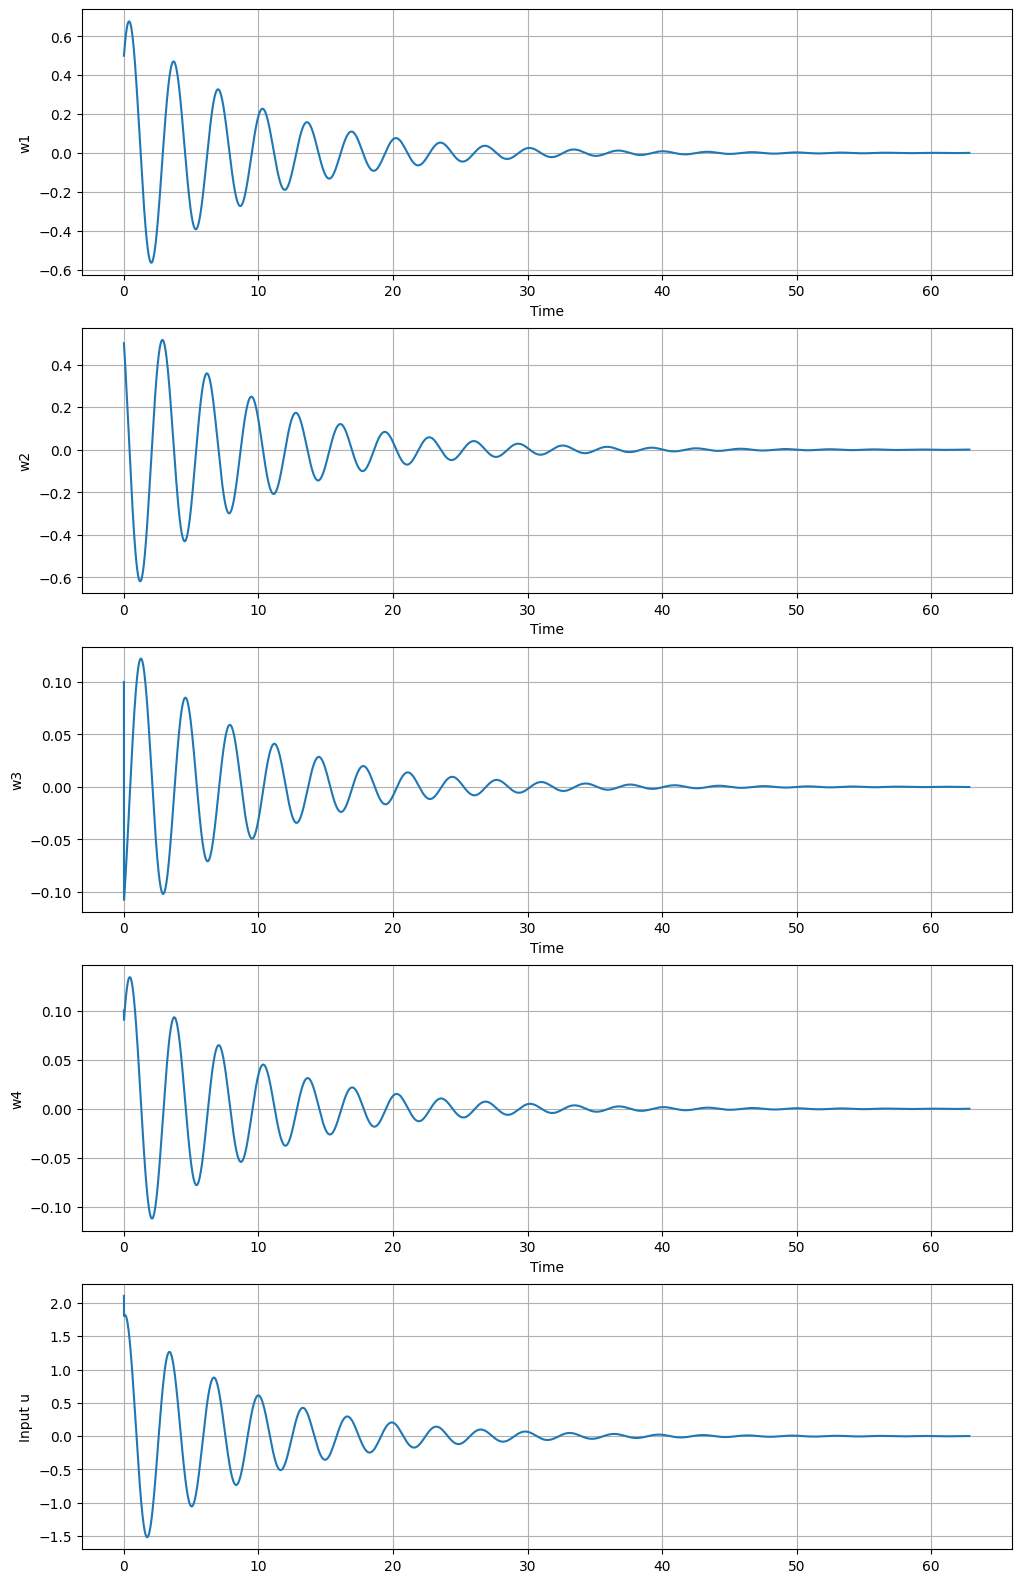

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.linalg as la

def signal(t, wg, S11, S12, S21, S22, epsilon):
    w1 = wg[:2]
    w2 = wg[2:]

    dw1 = S11 @ w1 + S12 @ w2
    dw2 = (1/epsilon) * (S21 @ w1 + S22 @ w2)

    return np.concatenate([dw1, dw2])

# Run the notebook with epsilon = 0.001 to see effect
epsilon = 0.0001

S11 = np.array([[-0.1 , 2.0],
                [-2.0, -0.1]])
S12 = np.array([[0.5, 0.],
                [0., 0.5]])

S21 = np.array([[-1., 0.,],
                [0., -1.]])
S22 = np.array([[-0.5, 5.],
                [-5., -0.5]])

Sg = np.block([[S11, S12],
               [(1/epsilon) * S21, (1/epsilon) * S22]])
print(Sg)
print(la.eigvals(S11))
print(la.eigvals(S12))
print(la.eigvals(S21))
print(la.eigvals(S22))

print(la.eigvals(Sg))



t_span = (0., 20.0*np.pi)
t_eval = np.linspace(t_span[0], t_span[1], 10000)

# initial condition for the signal 
w0 = [0.5, 0.5, 0.1, 0.1]
solw = solve_ivp(
    lambda t, state: signal(t, state,
                            S11 = S11,
                            S12 = S12,
                            S21 = S21, 
                            S22 = S22, 
                            epsilon = epsilon),
    t_span,
    w0, 
    t_eval = t_eval,
    method = 'Radau'
)

plt.figure(figsize = (12,20))
Wg = solw.y #Wg 
for i in range(4):
    Lg = np.zeros(4)
    Lg[i] = 1.0
    plt.subplot(5,1,i+1)
    print(Lg)
    plt.plot(solw.t, (Lg @ Wg).flatten())
    plt.xlabel("Time")
    plt.ylabel("w" + str(i+1))
    plt.grid(True)

Lg = np.array([[(4.0-i)**0.5 for i in range(4)]]) # Lg
print(Lg)
plt.subplot(5,1,5)
plt.plot(solw.t, (Lg@Wg).flatten())
plt.ylabel("Input u")
plt.grid(True)
plt.show()

We can see that w3 and w4 have fast smaller, fast oscillations during the beginning phase. 
As epsilon goes to zero, this tends towards a transient to match the slow manifold. 
As the signal is the singularly perturbed, we can find the slow manifold. 
Note the fast transient in w3. 
Setting $\varepsilon$ to zero, and writing $w_2$ in terms of $w_1$:

\begin{equation}
w_2 = -S_{22} ^{-1} S_{21} w_1
\end{equation}

\begin{equation}
\dot{w_1} = (S_{11}-S_{12} S_{22} ^{-1} S_{21}) w_1
\end{equation}

\begin{equation}
u = (L_{g1} - L_{g2} S_{22} ^ {-1} S_{21}) w_1
\end{equation}

[[2.         1.73205081 1.41421356 1.        ]]
[2.         1.73205081]
[1.41421356 1.        ]


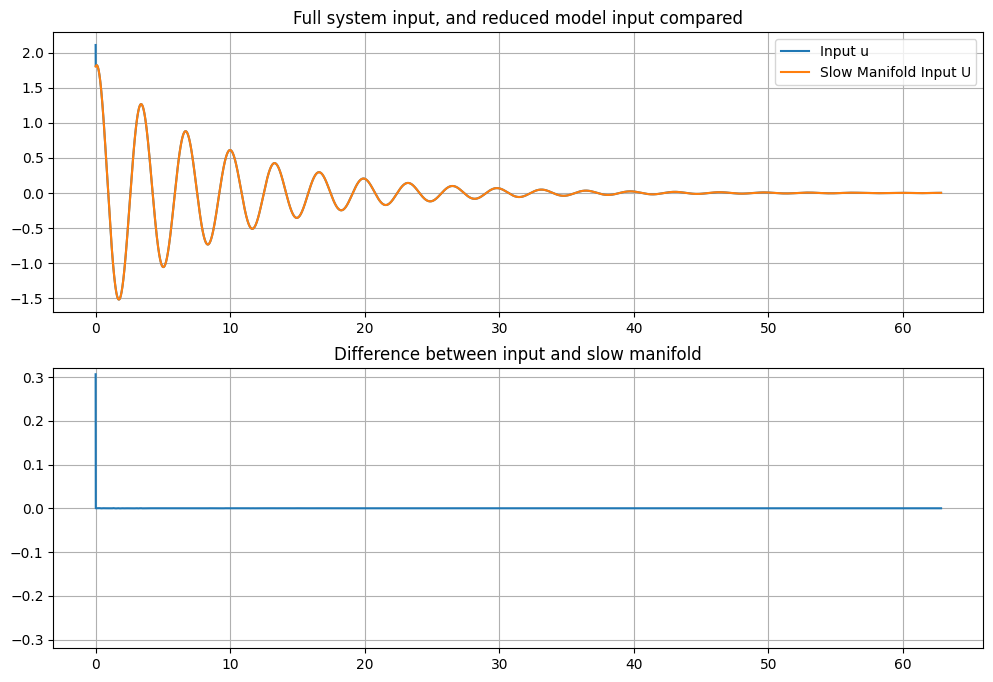

In [2]:
S22inv =  la.inv(S22)

def slow_manifold_signal(t, w, S11, S12, S21, S22):
    inverse = np.linalg.inv(S22)
    dw = (S11 - S12 @ inverse @ S21) @ w
    return dw

solwslow = solve_ivp(
    lambda t, state: slow_manifold_signal(t, state,
                            S11 = S11,
                            S12 = S12,
                            S21 = S21, 
                            S22 = S22),
    t_span,
    w0[:2],  # as we are only concerned with w1
    t_eval = t_eval,
    method = 'Radau'
)

Lg1 = Lg[0][:2]
Lg2 = Lg[0][2:]
w1 = solwslow.y 
print(Lg)
print(Lg1)
print(Lg2)
Uslow = (Lg1 - (Lg2 @ S22inv @ S21)) @ w1

plt.figure(figsize=(12,8))
plt.subplot(2,1,1)
plt.plot(solw.t, (Lg@Wg).flatten(), label = "Input u")
plt.plot(solw.t, Uslow.flatten(), label = 'Slow Manifold Input U')
plt.title("Full system input, and reduced model input compared")
plt.legend()
plt.grid(True)

# The difference between slow manifold and full signal
plt.subplot(2,1,2)
plt.plot(solw.t, ( (Lg@Wg) - Uslow ).flatten())
plt.title("Difference between input and slow manifold")
plt.ylim(-0.32, 0.32)
plt.grid(True)

plt.show()



Remark: Can a system that has noise added to it be modelled as a singularly perturbed system?

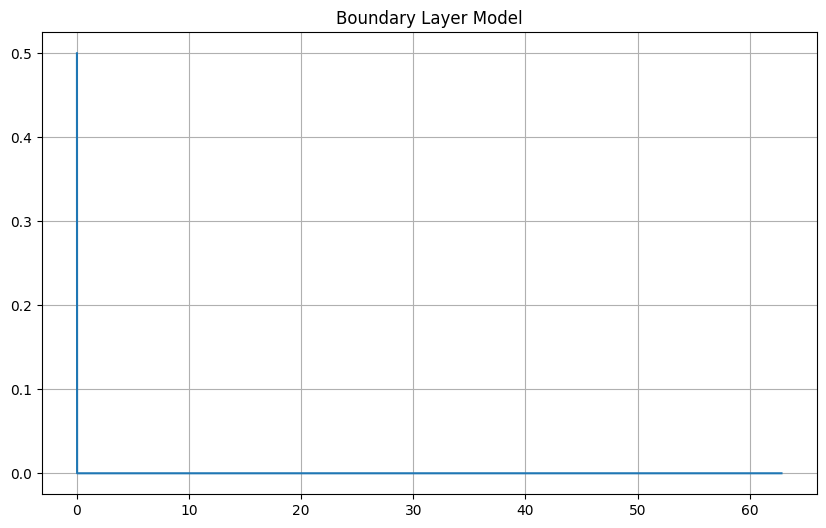

In [3]:
def boundary_layer(t, y, epsilon, S22):
    dy = (1/epsilon) * S22 @ y
    return dy

solboundary = solve_ivp(
    lambda t, state: boundary_layer(t, state, epsilon = epsilon, S22 = S22), 
    t_span,
    w0[:2],  # as we are only concerned with w1
    t_eval = t_eval,
    method = 'Radau'
)

y = solboundary.y
plt.figure(figsize = (10,6))
plt.plot(solboundary.t, (np.array([1.0,0.]) @ y).flatten())
plt.title("Boundary Layer Model")
plt.grid(True)
plt.show()



The boundary layer is t

Let's try simulating a singularly perturbed system. 
\begin{equation}
\dot{x}_1 = x_2 - z_2
\end{equation}

\begin{equation}
\dot{x}_2 = -x_1 - \beta x_2 + \beta z_2 + u
\end{equation}

\begin{equation}
\varepsilon \dot{z}_1 = z_2
\end{equation}

\begin{equation}
\varepsilon \dot{z}_2 = \alpha x_1 - \alpha \beta (z_2 - x_2) - z_1 - \alpha u 
\end{equation}

This can be written in the form: 
\begin{equation}
\dot{x} = A_{11} x + A_{12} z + B_1 u
\end{equation}

\begin{equation}
\varepsilon \dot{z} = A_{21} x + A_{22} z + B_2 u
\end{equation}

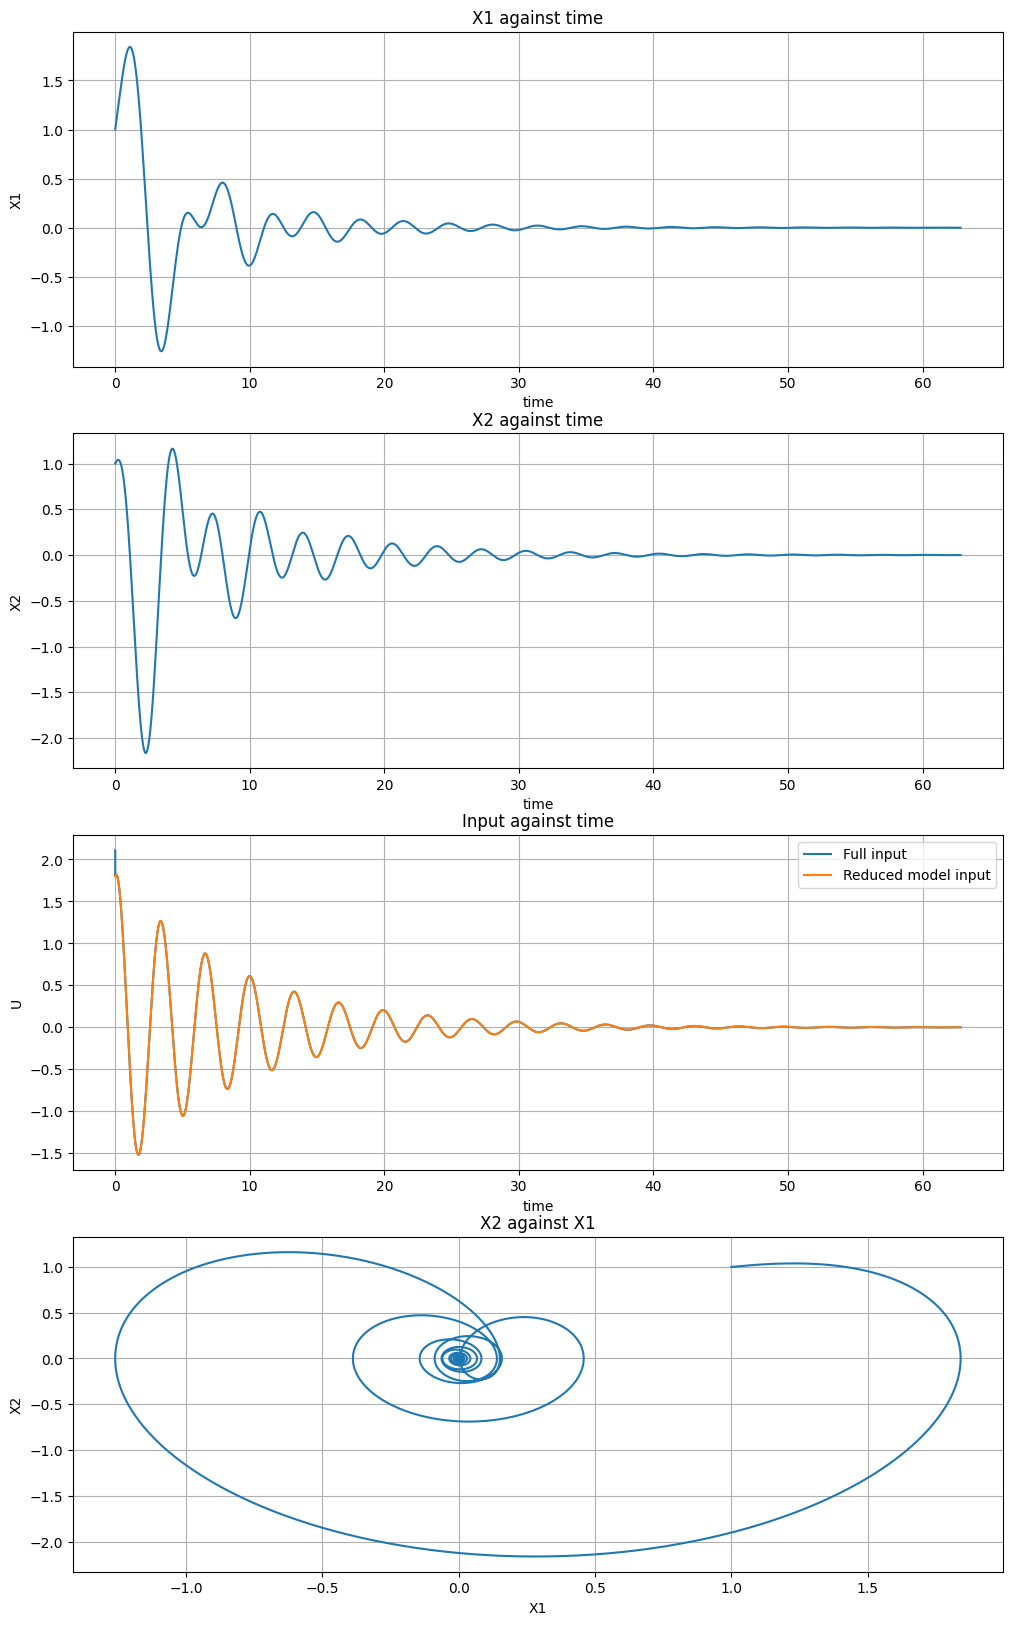

In [4]:
# constants
alpha = 1.0
beta = 0.5
A11 = np.array([[0., 1.],
                [-1., -beta]])
A12 = np.array([[0.,0.],
                [0.,beta]])
A21 = np.array([[0.,0.],
                [alpha, alpha * beta]])
A22 = np.array([[0., 1.0],
                [-1., -alpha * beta]])
B1 = np.array([[0.],
               [1.0]])
B2 = np.array([[0.],
               [-alpha]])

def combined_system(t, state): #x and z are state vectors, u is a single dimensional input
    x = state[:2]
    z = state[2:4]
    w1 = state[4:6]
    w2 = state[6:8]
    u = Lg1 @ w1 + Lg2 @ w2
    dx = A11 @ x + A12 @ z + B1.flatten() * u
    dz = (A21 @ x + A22 @ z + B2.flatten() * u) / epsilon
    dw1 = S11 @ w1 + S12 @ w2
    dw2 = (S21 @ w1 + S22 @ w2) / epsilon
    return np.concatenate( [dx, dz, dw1, dw2])

state0 = [1., 1., 2.,0.5, 0.5, 0.5, 0.1, 0.1]
sol = solve_ivp(combined_system, t_span, state0, t_eval=t_eval, method='Radau')

X = sol.y[:2, :]
Z = sol.y[2:4, :]
W1 = sol.y[4:6, :]
W2 = sol.y[6:8, :]
U = Lg1 @ W1 + Lg2 @ W2


C1 = np.array([[1.0,0.]])
C2 = np.array([[0.,1.]])

Y1 = C1 @ X
Y2 = C2 @ X


plt.figure(figsize = (12,20))

# Output reponse 1
plt.subplot(4,1,1) 
plt.plot( sol.t, Y1.flatten())
plt.title("X1 against time")
plt.grid(True)
plt.xlabel("time")
plt.ylabel("X1")

# Output response 2
plt.subplot(4,1,2)
plt.plot( sol.t, Y2.flatten())
plt.grid(True)
plt.title("X2 against time")
plt.xlabel("time")
plt.ylabel("X2")

# Input
plt.subplot(4,1,3)
plt.plot( sol.t, U.flatten(), label = 'Full input')
plt.plot( sol.t, Uslow.flatten(), label = 'Reduced model input')
plt.grid(True)
plt.legend()
plt.title("Input against time")
plt.xlabel("time")
plt.ylabel("U")


# Phase plane
plt.subplot(4,1,4)
plt.plot( Y1.flatten(), Y2.flatten())
plt.grid(True)
plt.title("X2 against X1")
plt.xlabel("X1")
plt.ylabel("X2")



plt.show()

Moments, numerically.
$\newline$
Let's solve the full Sylvester equation numerically using scipy. 

[-2.50000002e+03+9.68232927e+03j -2.50000002e+03-9.68232927e+03j
 -2.49981248e-01+9.68263587e-01j -2.49981248e-01-9.68263587e-01j]
[-4.99999010e+03+5.00000990e+04j -4.99999010e+03-5.00000990e+04j
 -1.09901522e-01+1.90098637e+00j -1.09901522e-01-1.90098637e+00j]
[[2.         1.73205081 1.41421356 1.        ]]
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 2.00000000e+00  1.73205081e+00  1.41421356e+00  1.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-2.00000000e+04 -1.73205081e+04 -1.41421356e+04 -1.00000000e+04]]
[[-6.81464812e-01 -6.75664203e-01  6.01464410e-06 -7.41678390e-06]
 [ 1.35932845e+00 -1.22119537e+00  3.35681522e-05 -1.59770737e-05]
 [-2.17781133e+00 -2.70517533e+00  6.26112630e-02  3.51225424e-02]
 [-6.20484498e-02 -3.55310530e-02 -2.07027234e-01  2.95359785e-01]]


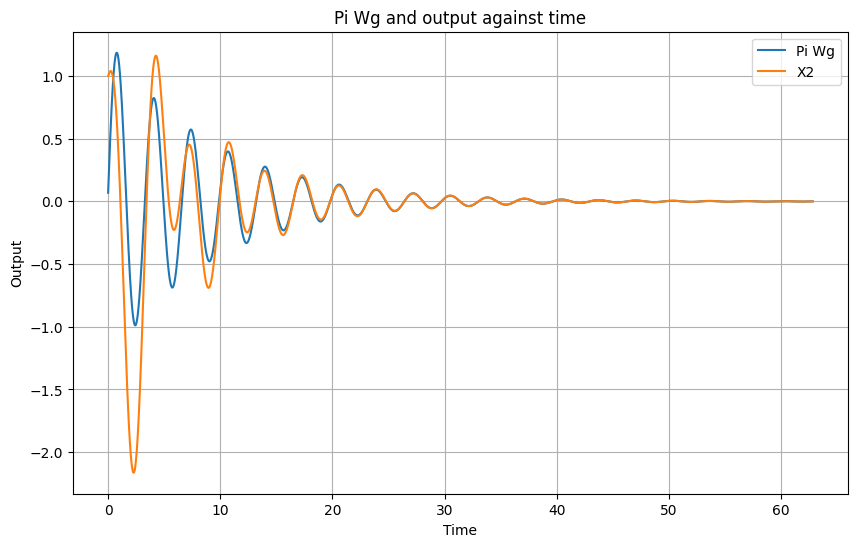

In [5]:
# Block matrix of A11, A12, A21, and A22
A_full = np.block([[A11, A12],
                   [(1/epsilon) * A21, (1/epsilon) * A22]])

print(la.eigvals(A_full))
print(la.eigvals(Sg))

# Block matrix for B
B_full = np.block([[B1], 
                   [(1/epsilon) * B2]])

C = np.array( [[0., 1.0, 0., 0.]])
print(Lg)
print( B_full @ Lg )

# Solving the Sylvester Equation for the full model
Pi_full = la.solve_sylvester( A_full, -Sg, -B_full @ Lg)
print( Pi_full )

Piw = Pi_full @ Wg
YPi = C @ Piw # Output with moments 

# Plotting 
plt.figure(figsize = (10,6))
plt.plot(sol.t, YPi.flatten(), label = "Pi Wg")
plt.plot(sol.t, Y2.flatten(), label  = "X2")
#plt.plot(sol.t, (Y1 - YPi).flatten())
plt.grid(True)
plt.xlabel("Time")
plt.ylabel("Output")
plt.title("Pi Wg and output against time")
plt.legend()
plt.show()


In [6]:
A22inv = la.inv(A22)
A_red = (A11 - (A12 @ A22inv @ A21))
B_red = (B1 - (A12  @ A22inv @ B2))
Sg_red = (S11 - (S12 @ S22inv @ S21))
Lg_red = [(Lg1 - (Lg2 @ S22inv @ S21))]

Pi_red = la.solve_sylvester( A_red, -Sg_red, -(B_red @ Lg_red))
print("Pi for the reduced model is given by: " + "\n" + str(Pi_red))
print("Pi for the full model is given by: " + "\n" + str(Pi_full))

Pi_x1 = Pi_full[:2, :2]
diff = np.abs(Pi_x1 - Pi_red)

print("Pi_x1 from the full system is given by: " + "\n" + str(Pi_x1))

print("the difference between the reduced model and Pi_x1 is given by: " + "\n" + str(diff))
print("The norm of the difference matrix is: " + "\n" + str(np.linalg.norm(diff)))


Pi for the reduced model is given by: 
[[-0.68134801 -0.67571519]
 [ 1.35940871 -1.22097406]]
Pi for the full model is given by: 
[[-6.81464812e-01 -6.75664203e-01  6.01464410e-06 -7.41678390e-06]
 [ 1.35932845e+00 -1.22119537e+00  3.35681522e-05 -1.59770737e-05]
 [-2.17781133e+00 -2.70517533e+00  6.26112630e-02  3.51225424e-02]
 [-6.20484498e-02 -3.55310530e-02 -2.07027234e-01  2.95359785e-01]]
Pi_x1 from the full system is given by: 
[[-0.68146481 -0.6756642 ]
 [ 1.35932845 -1.22119537]]
the difference between the reduced model and Pi_x1 is given by: 
[[1.16800147e-04 5.09888534e-05]
 [8.02643627e-05 2.21308868e-04]]
The norm of the difference matrix is: 
0.0002676978156754312


Investigating the relationship between them? $\newline$
Q: Is there someway of visualising the moments and comparing them?
The error is of order 0.001, ie of $O(\varepsilon)$.

As epsilon goes to a very small value, we can see that the 4 entries in the top left hand corner of the Pi matrix for the full model approaches that of the reduced model!

REDUCED MODEL

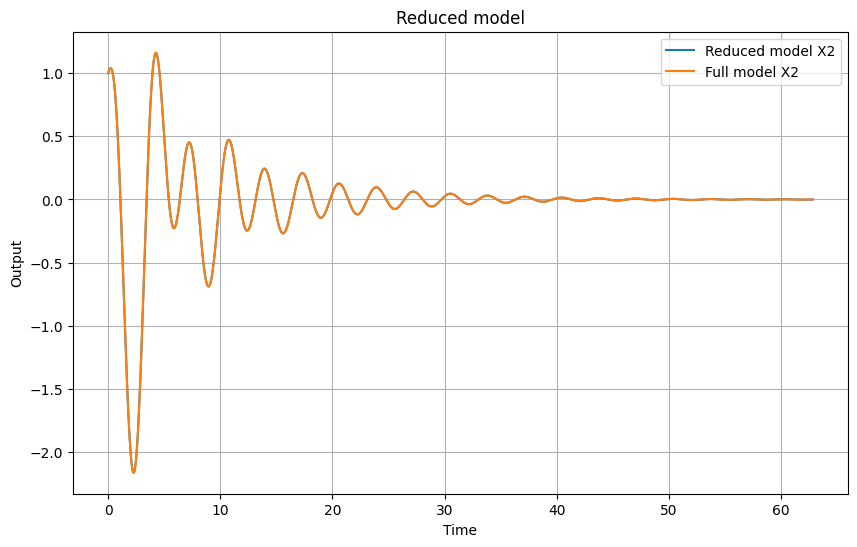

In [7]:
def combined_reduced_model(t, state):
    A22inv = la.inv(A22)
    x = state[0:2]
    w = state[2:]
    u = (Lg1 - (Lg2 @ S22inv @ S21))  @ w
    dx = (A11 - (A12 @ A22inv @ A21)) @ x + (B1 - (A12 @ A22inv @ B2)).flatten() * u
    dw = (S11 - (S12 @ S22inv @ S21)) @ w
    return np.concatenate([dx, dw])

state_red0 = [1., 1.,0.5, 0.5]
sol_reduced = solve_ivp(
    combined_reduced_model, t_span, state_red0, t_eval=t_eval, method = 'Radau')

X_red= sol_reduced.y[:2, :]
Y_red = C2 @ X_red
Y_red1 = C1 @ X_red


plt.figure( figsize = (10,6))
plt.plot(sol_reduced.t, Y_red.flatten(), label = 'Reduced model X2')
#plt.plot(sol_reduced.t, Y_red1.flatten(), label = "Reduced model X1")
plt.plot(sol.t, Y2.flatten(), label = "Full model X2")
plt.legend()
plt.grid(True)
plt.title("Reduced model")
plt.xlabel("Time")
plt.ylabel("Output")
# plt.xlim(0,5)
# plt.ylim(-1.5,-1.0)
plt.show()

So we can see that for small values of epsilon, the reduced model matches the full model closely, as expected.
Smaller the value of epsilon, the output from the full system approaches the trajectory of the reduced model quicker. 

next steps:
$\newline$
1. Produce plots for various values of epsilon
2. Moments - can we show that the forward sylvester equation tends towards the sylvester equation for the reduced model of the system? - Yes!
3. What signal do we need in terms of parametrised family of approximations for forward moments of approximating systems to match the forward moments of the system?
4. More examples? Non Hurwitz examples? 